# Car Price Prediction — PyTorch Deep MLP
**Why this version is different from the previous attempts:**

| Problem in previous version | Fix applied here |
|---|---|
| `BatchNorm1d` — causes train/eval discrepancy (running stats vs batch stats) | **Removed** — data already scaled by `StandardScaler` |
| LR=3e-4 too small → slow convergence | LR=**1e-3** (same as sklearn default) |
| Residual blocks — overkill for 1726 samples | Simple 3-layer MLP (256→128→64→1) |
| ReduceLROnPlateau + early stopping fighting each other | **Cosine Annealing Warm Restarts** — cycles LR independently |
| batch_size=64 — training & val stats mismatch | batch_size=**32** — more gradient updates per epoch |

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

from pytorch_model import CarPriceMLP

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [12]:
# 1. Load cleaned data
X_train = pd.read_csv('../data/train_clean.csv')
X_val   = pd.read_csv('../data/val_clean.csv')
X_test  = pd.read_csv('../data/test_clean.csv')

y_train = X_train.pop('price')
y_val   = X_val.pop('price')
y_test  = X_test.pop('price')

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

Train: (1726, 12)  |  Val: (216, 12)  |  Test: (216, 12)


In [13]:
# 2. Target: StandardScaler (same as sklearn pipeline)
target_scaler = StandardScaler()
y_train_s = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_s   = target_scaler.transform(y_val.values.reshape(-1, 1))
y_test_s  = target_scaler.transform(y_test.values.reshape(-1, 1))

In [14]:
# 3. Feature preprocessing (One-Hot + StandardScaler on numerics)
cat_features = ['gearbox_type', 'gearbox_health', 'motor_status',
                'body_status', 'chassis_status', 'brand']
num_features = ['year', 'mileage', 'car_age', 'yearly_mileage', 'has_insurance']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_tr = preprocessor.fit_transform(X_train)
X_va = preprocessor.transform(X_val)
X_te = preprocessor.transform(X_test)

print(f"Feature dimension: {X_tr.shape[1]}")

Feature dimension: 39


In [15]:
# 4. Convert to tensors and build DataLoaders
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_tr_t, y_tr_t = to_tensor(X_tr, y_train_s)
X_va_t, y_va_t = to_tensor(X_va, y_val_s)
X_te_t, y_te_t = to_tensor(X_te, y_test_s)

# batch_size=32 → ~54 updates/epoch vs sklearn's 9 — more stable gradient signal
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=256, shuffle=False)

In [16]:
# 5. Model, Loss, Optimizer, Scheduler
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = X_tr.shape[1]
model     = CarPriceMLP(input_dim).to(device)
criterion = nn.MSELoss()

# Adam lr=1e-3 — same as sklearn default; weight_decay adds light L2
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# CosineAnnealingWarmRestarts: avoids LR collapsing to near-zero like ReduceLROnPlateau
# T_0=100 → first cycle is 100 epochs, resets and doubles each restart
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=100, T_mult=2, eta_min=1e-6
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Model parameters: {n_params:,}")
print(model)

Device: cuda
Model parameters: 4,673
CarPriceMLP(
  (network): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [17]:
# 6. Training loop
MAX_EPOCHS     = 3000
PATIENCE       = 150   # generous: wait 150 epochs before giving up
best_val_loss  = float('inf')
patience_ctr   = 0
train_losses, val_losses = [], []

os.makedirs('saved_models', exist_ok=True)

print("Training...")
for epoch in range(MAX_EPOCHS):

    # -- Train --
    model.train()
    run = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        run += loss.item() * xb.size(0)
    tr_loss = run / len(train_loader.dataset)

    # -- Validate --
    model.eval()
    with torch.no_grad():
        va_loss = criterion(
            model(X_va_t.to(device)), y_va_t.to(device)
        ).item()

    scheduler.step(epoch + 1)   # CosineAnnealingWarmRestarts needs epoch as arg

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if (epoch + 1) % 100 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:4d}  |  Train: {tr_loss:.4f}  |  Val: {va_loss:.4f}  |  LR: {lr_now:.2e}")

    # Early stopping — track best val
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), 'saved_models/best_model.pth')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}  (best val loss: {best_val_loss:.4f})")
            break

print("Done.")

Training...
Epoch  100  |  Train: 0.1867  |  Val: 0.3001  |  LR: 1.00e-03

Early stopping at epoch 165  (best val loss: 0.2717)
Done.


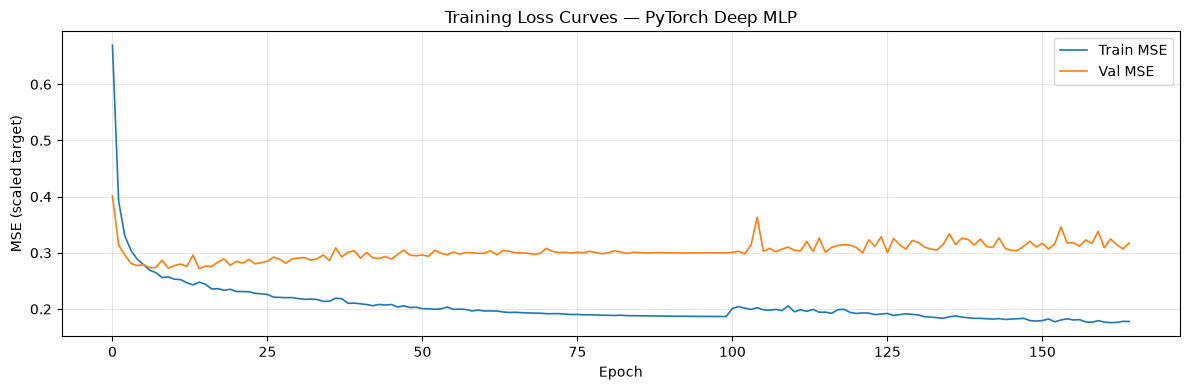

In [18]:
# 7. Loss curves
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_losses, label='Train MSE', linewidth=1.2)
ax.plot(val_losses,   label='Val MSE',   linewidth=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled target)')
ax.set_title('Training Loss Curves — PyTorch Deep MLP')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [19]:
# 8. Evaluation on best checkpoint
model.load_state_dict(torch.load('saved_models/best_model.pth', weights_only=True))
model.eval()

with torch.no_grad():
    tr_pred_s  = model(X_tr_t.to(device)).cpu().numpy()
    va_pred_s  = model(X_va_t.to(device)).cpu().numpy()
    te_pred_s  = model(X_te_t.to(device)).cpu().numpy()

# Inverse transform
tr_pred = target_scaler.inverse_transform(tr_pred_s)
va_pred = target_scaler.inverse_transform(va_pred_s)
te_pred = target_scaler.inverse_transform(te_pred_s)

print("=" * 50)
print("  R2  (scaled target — what model optimized)")
print("=" * 50)
print(f"  Train : {r2_score(y_train_s, tr_pred_s):.4f}")
print(f"  Val   : {r2_score(y_val_s,   va_pred_s):.4f}")
print(f"  Test  : {r2_score(y_test_s,  te_pred_s):.4f}")

print()
print("=" * 50)
print("  R2  (real Toman prices)")
print("=" * 50)
print(f"  Train : {r2_score(y_train, tr_pred):.4f}")
print(f"  Val   : {r2_score(y_val,   va_pred):.4f}")
print(f"  Test  : {r2_score(y_test,  te_pred):.4f}")

  R2  (scaled target — what model optimized)
  Train : 0.7657
  Val   : 0.7223
  Test  : 0.7752

  R2  (real Toman prices)
  Train : 0.7657
  Val   : 0.7223
  Test  : 0.7752


In [20]:
# 9. Save artifacts
os.makedirs('saved_models', exist_ok=True)
joblib.dump(preprocessor,  'saved_models/pytorch_preprocessor.pkl')
joblib.dump(target_scaler, 'saved_models/target_scaler.pkl')
torch.save(model.state_dict(), 'saved_models/pytorch_model.pth')

print("Saved:")
print("  saved_models/pytorch_preprocessor.pkl")
print("  saved_models/target_scaler.pkl")
print("  saved_models/pytorch_model.pth")

Saved:
  saved_models/pytorch_preprocessor.pkl
  saved_models/target_scaler.pkl
  saved_models/pytorch_model.pth
